# PyMossDist-V2
## Distribución de campos magnéticos hiperfinos (Hesse-Rübartsch style)

Ajusta espectros Mössbauer de ⁵⁷Fe con una distribución de B_hf usando
grid fijo y mínimos cuadrados no negativos (NNLS), con IS, QS y γ libres.

Basado en: PyMossFit (Saccone, 2025) y el método de Hesse-Rübartsch.
Ideal para aleaciones nanocristalinas/amorfas (Finemet, etc.).

In [1]:
# Celda 1: Setup
!pip install lmfit numdifftools -q

from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

# --- CONFIGURAR ESTO ---
img = '/content/drive/MyDrive/Colab-Notebooks/PyMossDist/Cr_2/ABFE71_5.mos'  # archivo calibrado
# -----------------------

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import nnls
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

path = Path(img); file = path.stem; title = path.parent.name; full = path.parents[0]
print(f'Archivo: {file}\nCarpeta: {title}\nRuta: {full}')

# Constantes ⁵⁷Fe (shifts físicos exactos)
SHIFTS_57FE = np.array([-1.000, -0.579, -0.158, 0.158, 0.579, 1.000])
INT_57FE = np.array([3, 2, 1, 1, 2, 3])
# Factor de conversión: B_hf(T) = outer_mms × k_T_per_mms
# α-Fe: pos outer = 5.34 mm/s → B_hf = 33.0 T
K_T_MMS = 33.0 / 5.34  # ≈ 6.18

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.6 MB/s eta 0:00:00
Mounted at /content/drive/
Archivo: ABFE71_5
Carpeta: Cr_2
Ruta: /content/drive/MyDrive/Colab-Notebooks/PyMossDist/Cr_2


Ingrese la fecha de calibración (AAAAMMDD): 20141203
Ingrese el rango de V (en mm/s): -9.8


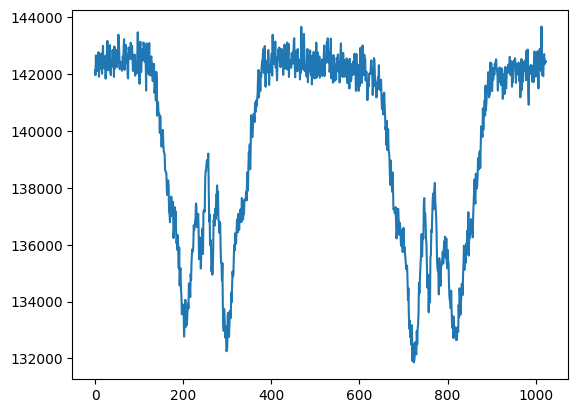

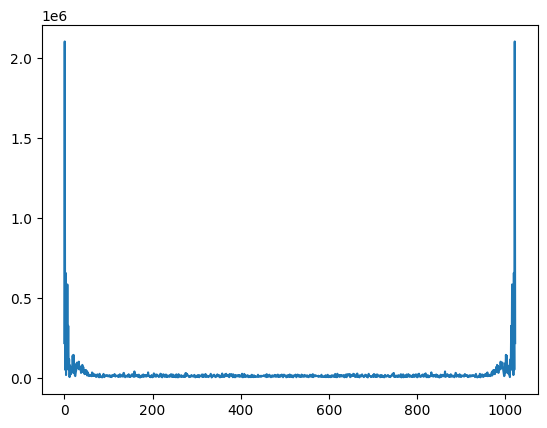

Media del fondo: 284805
Canal de doblado: 512


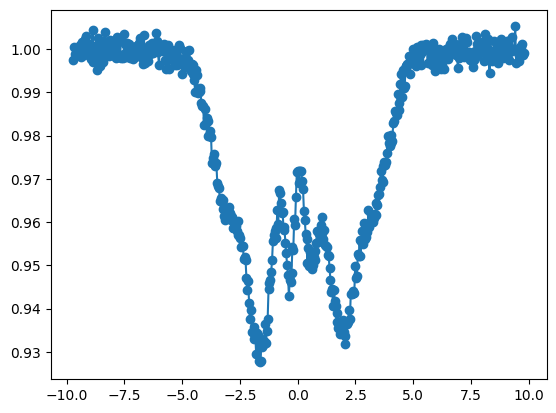

In [2]:
"""
Para doblar, normalizar y calibrar en mm/s, los archivos del espectrómetro de INTECIN de 1024 canales o CNEA de 512
"""
y= np.loadtxt(img, skiprows=0); #y=y[:,1] #agregar delivery=" " o delimiter=" " en loadtxt si es de dos columnas. Caso contrario comentar y=y[:,1]
N=len(y); N2=int(N/2); N4=int(N/4)

fecha = str(input('Ingrese la fecha de calibración (AAAAMMDD): '),)
vel = float(input('Ingrese el rango de V (en mm/s): ' ), )
np.savetxt(f"{full}/{file}-calib.txt", (fecha,vel, N), fmt='%s')

#y= savgol_filter(y, 5, 2) #solo si se trata de espectro con baja estadística, comentar en otro caso
plt.plot(y)
plt.show()

"""
Doblado con FFT (basado en el Nyquist-Shannon sampling theorem, https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter24.02-Discrete-Fourier-Transform.html)
"""
f= abs(np.fft.fft(y)); Nf=pd.Series(f[N2-1:N2+1]).idxmax()+(N2-1)
plt.plot(f[1:N])
plt.show()

for i in range(0, Nf-1):
    y[[i]]=y[[i]]+y[[N-1-i]]

y=y[0:N2-1]

"""
Normalización
"""
y2= np.concatenate([y[2:30],y[N2-30:N2-2]])

ymax=np.mean(y2)
ymax=int(ymax)

for i in range(0, N2-1):
    y[[i]]=y[[i]]/ymax

x=np.arange(1,N2)

"""
de canales a escala de velocidades en mm/s
"""
v=np.loadtxt(f"{full}/{file}-calib.txt"); vmax=v[[1]]

x=np.linspace(start = 0, stop = N2-1, num= N2)

for i in range(0, N2-1):
    x[[i]]=(i-N4)*vmax/N4

x= x[0:N2-1]

print('Media del fondo:', ymax); print('Canal de doblado:', Nf)

plt.plot(x,y, marker="o")
plt.show()

np.savetxt(f"{full}/{file}.csv", list(zip(x,y)), delimiter=",", fmt='%1.6f')

## Funciones base

In [3]:
# Celda 2: Funciones

def lorentzian(v, center, gamma):
    """Lorentziana unitaria (pico = 1)"""
    return (gamma/2)**2 / ((v - center)**2 + (gamma/2)**2)

def sextet_57fe(v, is_shift, bhf_outer, gamma):
    """Sexteto de ⁵⁷Fe.
    bhf_outer: posición de la línea externa desde el centro (mm/s)
    """
    positions = is_shift + SHIFTS_57FE * bhf_outer
    y = np.zeros_like(v)
    for i in range(6):
        y += INT_57FE[i] * lorentzian(v, positions[i], gamma)
    return y

def build_design_matrix(v, is_shift, gamma, bhf_grid):
    """Construye matriz A donde cada columna es un sexteto del grid.
    La salida es la absortancia (1 - transmisión) para NNLS.
    """
    n = len(v)
    m = len(bhf_grid)
    A = np.zeros((n, m))
    for j in range(m):
        y = sextet_57fe(v, is_shift, bhf_grid[j], gamma)
        # Normalizar a área unitaria
        peak = y.max()
        if peak > 0:
            y = y / peak
        A[:, j] = y  # columna = perfil del sexteto para este campo
    return A

def transmission_from_weights(v, weights, is_shift, gamma, bhf_grid):
    """Reconstruye el espectro de transmisión desde la distribución."""
    A = build_design_matrix(v, is_shift, gamma, bhf_grid)
    absorption = A @ weights
    return 1 - absorption

def smoothness_penalty(weights):
    """Regularización Tikhonov: penaliza diferencias entre bins vecinos."""
    return np.sum(np.diff(weights)**2)

## Optimización de IS y γ + NNLS

Hace una grilla 2D de (IS, γ) y para cada par resuelve NNLS.
Elige el par que minimiza χ².

In [5]:
# Celda 3: Optimización

# Cargar datos
v_data, y_data = np.loadtxt(f"{full}/{file}.csv", delimiter=",", unpack=True)
absorption = 1 - y_data
n_data = len(v_data)
print(f'Datos: {n_data} puntos, rango v: [{v_data[0]:.2f}, {v_data[-1]:.2f}] mm/s')

# Grid de B_hf
# Para Finemet con Cr: campos reducidos. Ajustar según muestra.
BHF_MIN = 1.0    # mm/s (outer position)
BHF_MAX = 6.0    # mm/s (outer position, α-Fe ≈ 5.34)
N_BINS = 30
bhf_grid = np.linspace(BHF_MIN, BHF_MAX, N_BINS)
bhf_grid_T = bhf_grid * K_T_MMS  # en Tesla
print(f'Grid B_hf: {N_BINS} bins, {bhf_grid[0]:.2f}-{bhf_grid[-1]:.2f} mm/s '
      f'({bhf_grid_T[0]:.1f}-{bhf_grid_T[-1]:.1f} T)')

# Grilla de IS y γ
# IS típico para α-Fe(Si): ~0.0-0.3 mm/s
# Para Finemet con Cr: puede ser levemente positivo
IS_VALUES = np.linspace(-0.3, 0.4, 15)
GAMMA_VALUES = np.linspace(0.2, 0.6, 9)  # gamma esperado 0.25-0.45

best_chisq = np.inf
best_is = 0.0
best_gamma = 0.3
best_weights = None
best_A = None

n_is = len(IS_VALUES)
n_gamma = len(GAMMA_VALUES)
total = n_is * n_gamma
count = 0

print(f'\nOptimizando IS y γ ({n_is}×{n_gamma} = {total} combinaciones)...')
print('  IS    γ     χ²       bins>0')
print('  ' + '-'*30)

for is_val in IS_VALUES:
    for gamma_val in GAMMA_VALUES:
        count += 1
        A = build_design_matrix(v_data, is_val, gamma_val, bhf_grid)

        # NNLS
        w, residual = nnls(A, absorption)
        chisq = residual / (n_data - 1)  # aprox χ² reducido

        if chisq < best_chisq:
            best_chisq = chisq
            best_is = is_val
            best_gamma = gamma_val
            best_weights = w.copy()
            best_A = A.copy()

        if count % 15 == 0 or chisq == best_chisq:
            nz = np.sum(w > 1e-4)
            print(f'  {is_val:+.2f}  {gamma_val:.2f}  {chisq:.2e}  {nz}')

print(f'\nMejor: IS={best_is:.3f} mm/s, γ={best_gamma:.3f} mm/s, χ²_red={best_chisq:.2e}')

# Reconstruir
y_fit = 1 - best_A @ best_weights
residual_std = np.std(y_data - y_fit)
print(f'σ residual = {residual_std:.5f}')

# Aplicar regularización opcional (Tikhonov, λ=rango automático)
# Primero: pesos sin regularizar ya están.
# Si quedan muchos bins ruidosos, aplicar smooth posterior.
weights_smooth = best_weights.copy()
from scipy.ndimage import gaussian_filter1d
weights_smooth = gaussian_filter1d(weights_smooth, sigma=0.7, mode='constant')
y_fit_smooth = 1 - best_A @ weights_smooth
residual_smooth = np.std(y_data - y_fit_smooth)
print(f'σ residual (suavizado) = {residual_smooth:.5f}')

# Elegir la versión con mejor compromiso
if residual_smooth < residual_std * 1.15:
    # El suavizado no degrada mucho, usar versión suavizada
    weights_final = weights_smooth
    y_fit_final = y_fit_smooth
    print('Usando distribución suavizada')
else:
    weights_final = best_weights
    y_fit_final = y_fit
    print('Usando distribución sin suavizar')

Datos: 511 puntos, rango v: [9.80, -9.72] mm/s
Grid B_hf: 30 bins, 1.00-6.00 mm/s (6.2-37.1 T)

Optimizando IS y γ (15×9 = 135 combinaciones)...
  IS    γ     χ²       bins>0
  ------------------------------
  -0.30  0.20  3.74e-04  29
  -0.30  0.25  3.60e-04  29
  -0.30  0.30  3.50e-04  28
  -0.30  0.35  3.40e-04  26
  -0.30  0.40  3.32e-04  25
  -0.30  0.45  3.26e-04  24
  -0.30  0.50  3.20e-04  22
  -0.30  0.55  3.16e-04  22
  -0.30  0.60  3.12e-04  19
  -0.25  0.40  3.09e-04  26
  -0.25  0.45  3.03e-04  24
  -0.25  0.50  2.97e-04  22
  -0.25  0.55  2.93e-04  20
  -0.25  0.60  2.89e-04  18
  -0.20  0.40  2.81e-04  26
  -0.20  0.45  2.75e-04  23
  -0.20  0.50  2.70e-04  22
  -0.20  0.55  2.66e-04  18
  -0.20  0.60  2.63e-04  16
  -0.15  0.30  2.65e-04  25
  -0.15  0.35  2.56e-04  25
  -0.15  0.40  2.50e-04  24
  -0.15  0.45  2.44e-04  23
  -0.15  0.50  2.40e-04  18
  -0.15  0.55  2.37e-04  17
  -0.15  0.60  2.34e-04  15
  -0.10  0.30  2.28e-04  27
  -0.10  0.35  2.20e-04  24
  -0.10 

## Reporte y gráficos


REPORTE DEL AJUSTE
IS = 0.1000 ± 0.0? mm/s
γ  = 0.4000 mm/s
N_bins = 30
σ residual = 0.00207

Picos significativos (>0.00063):
  B_hf(mm/s)  B_hf(T)    Peso
  -------------------------
  1.172      7.2     0.00128
  1.345      8.3     0.00510
  1.517      9.4     0.00809
  1.690      10.4     0.00931
  1.862      11.5     0.00873
  2.034      12.6     0.01072
  2.207      13.6     0.01051
  2.379      14.7     0.01039
  2.552      15.8     0.01094
  2.724      16.8     0.01139
  2.897      17.9     0.01217
  3.069      19.0     0.01081
  3.241      20.0     0.01250
  3.414      21.1     0.01048
  3.586      22.2     0.00856
  3.759      23.2     0.00677
  3.931      24.3     0.00549
  4.103      25.4     0.00404
  4.276      26.4     0.00268
  4.448      27.5     0.00084

Distribución guardada: ABFE71_5-dist.csv
Reporte guardado: ABFE71_5-report-dist.csv


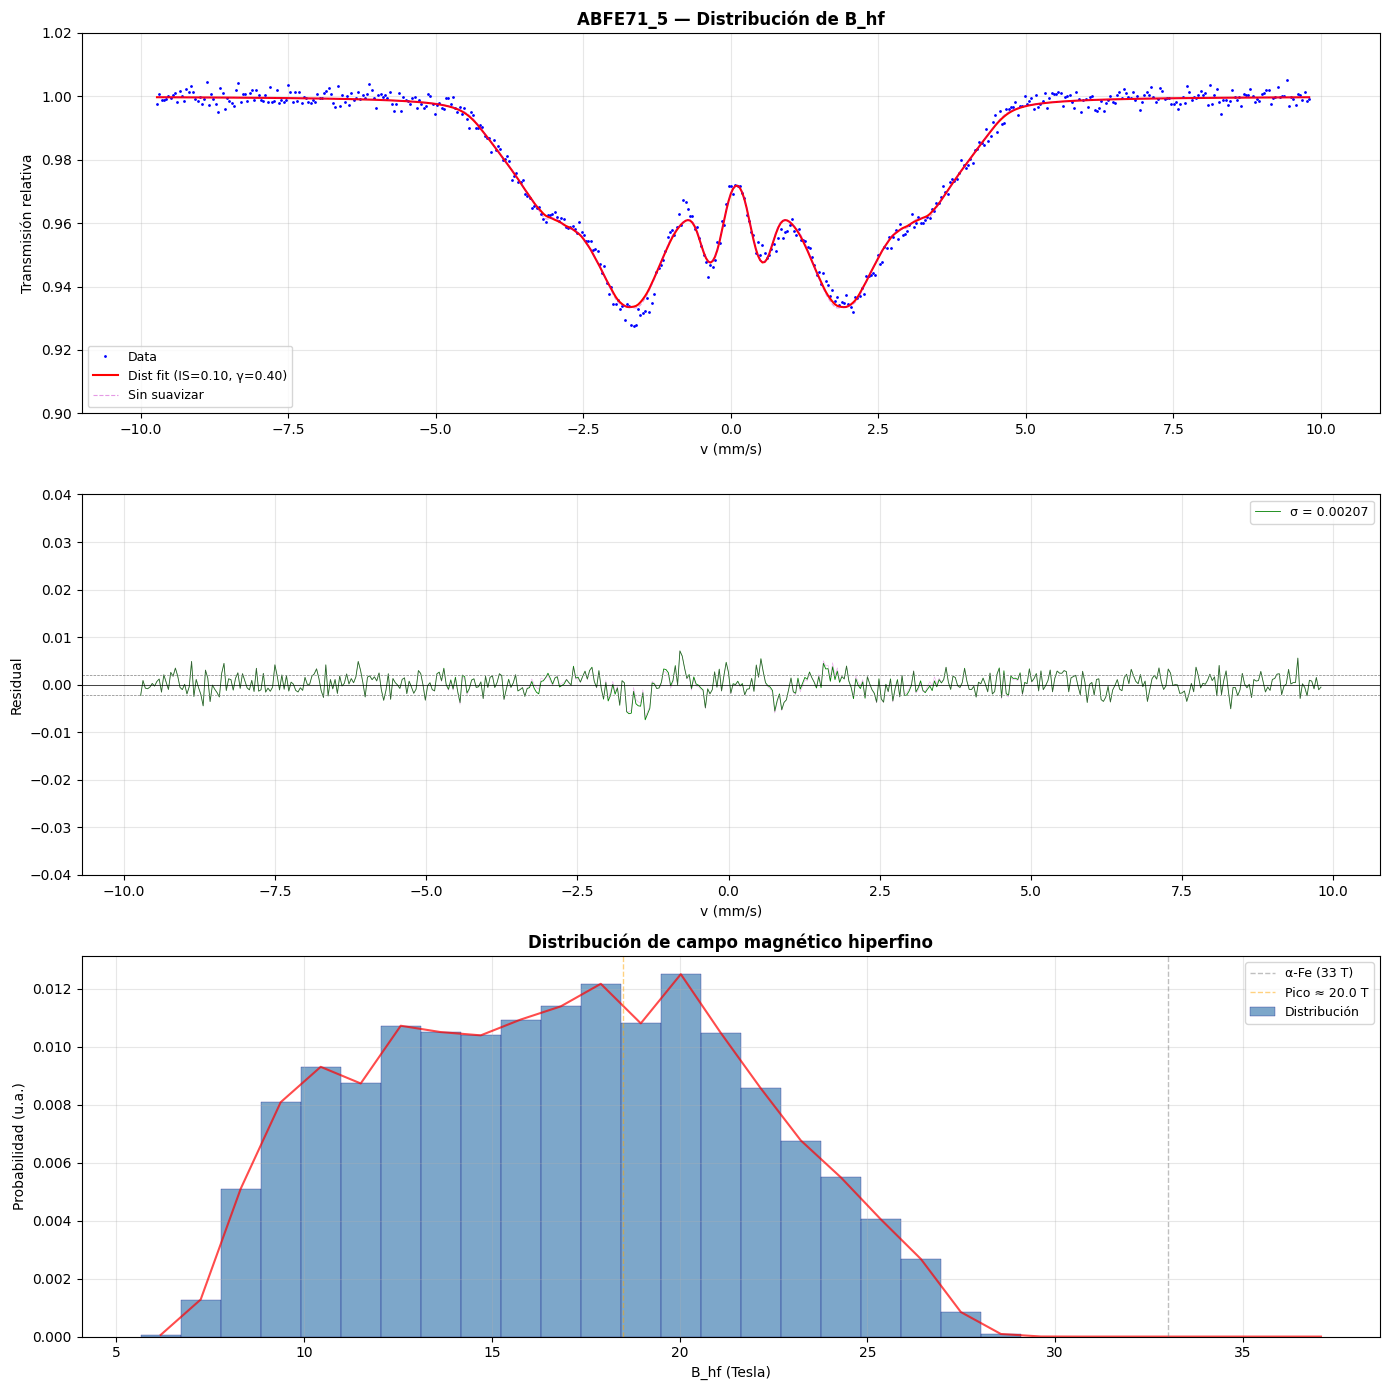

Gráfico guardado: ABFE71_5-dist.png


In [6]:
# Celda 4: Reporte y gráficos

# Reporte de parámetros
print('\n' + '='*60)
print('REPORTE DEL AJUSTE')
print('='*60)
print(f'IS = {best_is:.4f} ± 0.0? mm/s')
print(f'γ  = {best_gamma:.4f} mm/s')
print(f'N_bins = {N_BINS}')
print(f'σ residual = {residual_std:.5f}')

# Picos de la distribución
sig = weights_final > weights_final.max() * 0.05
print(f'\nPicos significativos (>{weights_final.max()*0.05:.5f}):')
print('  B_hf(mm/s)  B_hf(T)    Peso')
print('  ' + '-'*25)
for j in np.where(sig)[0]:
    print(f'  {bhf_grid[j]:.3f}      {bhf_grid_T[j]:.1f}     {weights_final[j]:.5f}')

# Guardar distribución
df_dist = pd.DataFrame({
    'B_hf_mms': bhf_grid,
    'B_hf_T': bhf_grid_T,
    'Weight': weights_final
})
df_dist.to_csv(f'{full}/{file}-dist.csv', index=False)
print(f'\nDistribución guardada: {file}-dist.csv')

# Guardar report
df_report = pd.DataFrame([{
    'IS_mms': best_is,
    'Gamma_mms': best_gamma,
    'N_bins': N_BINS,
    'BHF_min_mms': BHF_MIN,
    'BHF_max_mms': BHF_MAX,
    'Residual_std': residual_std,
    'Chisq_red': best_chisq
}])
df_report.to_csv(f'{full}/{file}-report-dist.csv', index=False)
print(f'Reporte guardado: {file}-report-dist.csv')

# ======================== GRÁFICOS ========================
fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# 1) Espectro
axes[0].plot(v_data, y_data, 'b.', markersize=2, label='Data')
axes[0].plot(v_data, y_fit_final, 'r-', lw=1.5,
             label=f'Dist fit (IS={best_is:.2f}, γ={best_gamma:.2f})')
axes[0].plot(v_data, y_fit, 'm--', lw=0.8, alpha=0.4, label='Sin suavizar')
axes[0].fill_between([-10, 10], -0.02, 0.02, alpha=0.03, color='gray')
axes[0].set_xlabel('v (mm/s)'); axes[0].set_ylabel('Transmisión relativa')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)
axes[0].set_title(f'{file} — Distribución de B_hf', fontweight='bold')
axes[0].set_ylim(0.9,1.02)

# 2) Residual
res = y_data - y_fit_final
axes[1].plot(v_data, res, 'g-', lw=0.6, label=f'σ = {residual_std:.5f}')
axes[1].plot(v_data, y_data - y_fit, 'm-', lw=0.3, alpha=0.4)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].axhline( residual_std, color='gray', ls='--', lw=0.5)
axes[1].axhline(-residual_std, color='gray', ls='--', lw=0.5)
axes[1].set_xlabel('v (mm/s)'); axes[1].set_ylabel('Residual')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_ylim(-0.04, 0.04)

# 3) Distribución
nonzero = weights_final > 1e-5
axes[2].bar(bhf_grid_T[nonzero], weights_final[nonzero],
            width=(bhf_grid_T[1]-bhf_grid_T[0]),
            alpha=0.7, color='steelblue', edgecolor='navy', lw=0.3,
            label='Distribución')
axes[2].plot(bhf_grid_T, weights_final, 'r-', lw=1.5, alpha=0.7)
# Referencias
axes[2].axvline(33.0, color='gray', ls='--', lw=1, alpha=0.5, label='α-Fe (33 T)')
axes[2].axvline(18.5, color='orange', ls='--', lw=1, alpha=0.5,
                label=f'Pico ≈ {bhf_grid_T[weights_final.argmax()]:.1f} T')
axes[2].set_xlabel('B_hf (Tesla)')
axes[2].set_ylabel('Probabilidad (u.a.)')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)
axes[2].set_title('Distribución de campo magnético hiperfino', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{full}/{file}-dist.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico guardado: {file}-dist.png')

## Análisis de fases (KNN)

Usa los picos principales de la distribución para sugerir fases presentes
comparando con la base de datos de referencia.

In [ ]:
# Celda 5: KNN (opcional, requiere reference_data.csv)

try:
    from sklearn.neighbors import NearestNeighbors

    ref_path = '/content/drive/MyDrive/reference_data.csv'
    df_ref = pd.read_csv(ref_path)

    def parse_value(value):
        if isinstance(value, str) and '-' in value:
            lo, hi = map(float, value.split('-'))
            return (lo + hi) / 2
        return float(value)

    # Encontrar picos principales en la distribución
    from scipy.signal import find_peaks
    peak_idx, _ = find_peaks(weights_final, height=weights_final.max()*0.1, distance=3)

    if len(peak_idx) > 0:
        print('\n' + '='*60)
        print('SUGERENCIA DE FASES (KNN)')
        print('='*60)

        for k, pidx in enumerate(peak_idx):
            bhf_val = bhf_grid_T[pidx]
            is_val = best_is

            # Buscar en DB
            features = []
            for _, row in df_ref.iterrows():
                try:
                    is_db = parse_value(row['IS (mm/s)'])
                    bhf_db = parse_value(str(row.get('Bhf (T)', 0)))
                    d = np.sqrt((is_val - is_db)**2 + (bhf_val/10 - bhf_db/10)**2)
                    features.append((d, row['Compound'], row.get('Formula', ''), is_db, bhf_db))
                except:
                    continue

            features.sort(key=lambda x: x[0])
            print(f'\nPico {k+1}: B_hf ≈ {bhf_val:.1f} T')
            for j in range(min(3, len(features))):
                d, comp, form, is_db, bhf_db = features[j]
                print(f'  → {comp} ({form}): IS={is_db:.2f}, B_hf={bhf_db:.1f} T, d={d:.2f}')
    else:
        print('No se detectaron picos significativos en la distribución.')

except FileNotFoundError:
    print('\n⚠ reference_data.csv no encontrado. Saltando KNN.')
    print(f'  Buscado en: {ref_path}')
except Exception as e:
    print(f'\n⚠ KNN falló: {e}')


⚠ reference_data.csv no encontrado. Saltando KNN.
  Buscado en: /content/drive/MyDrive/reference_data.csv
